In [8]:
import obspy
data = obspy.read('../RAW/*.SAC')
import matplotlib.pyplot as plt

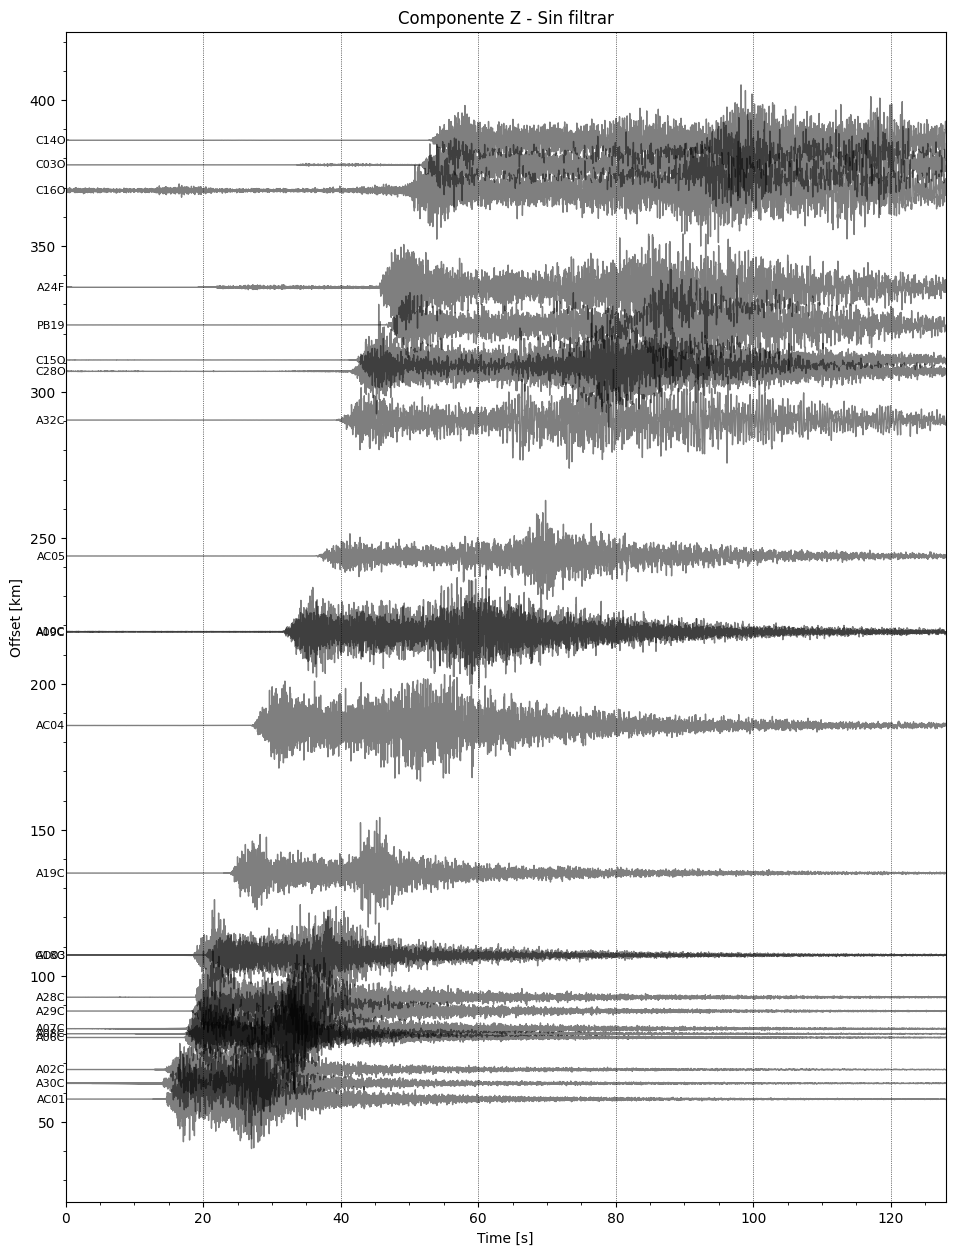

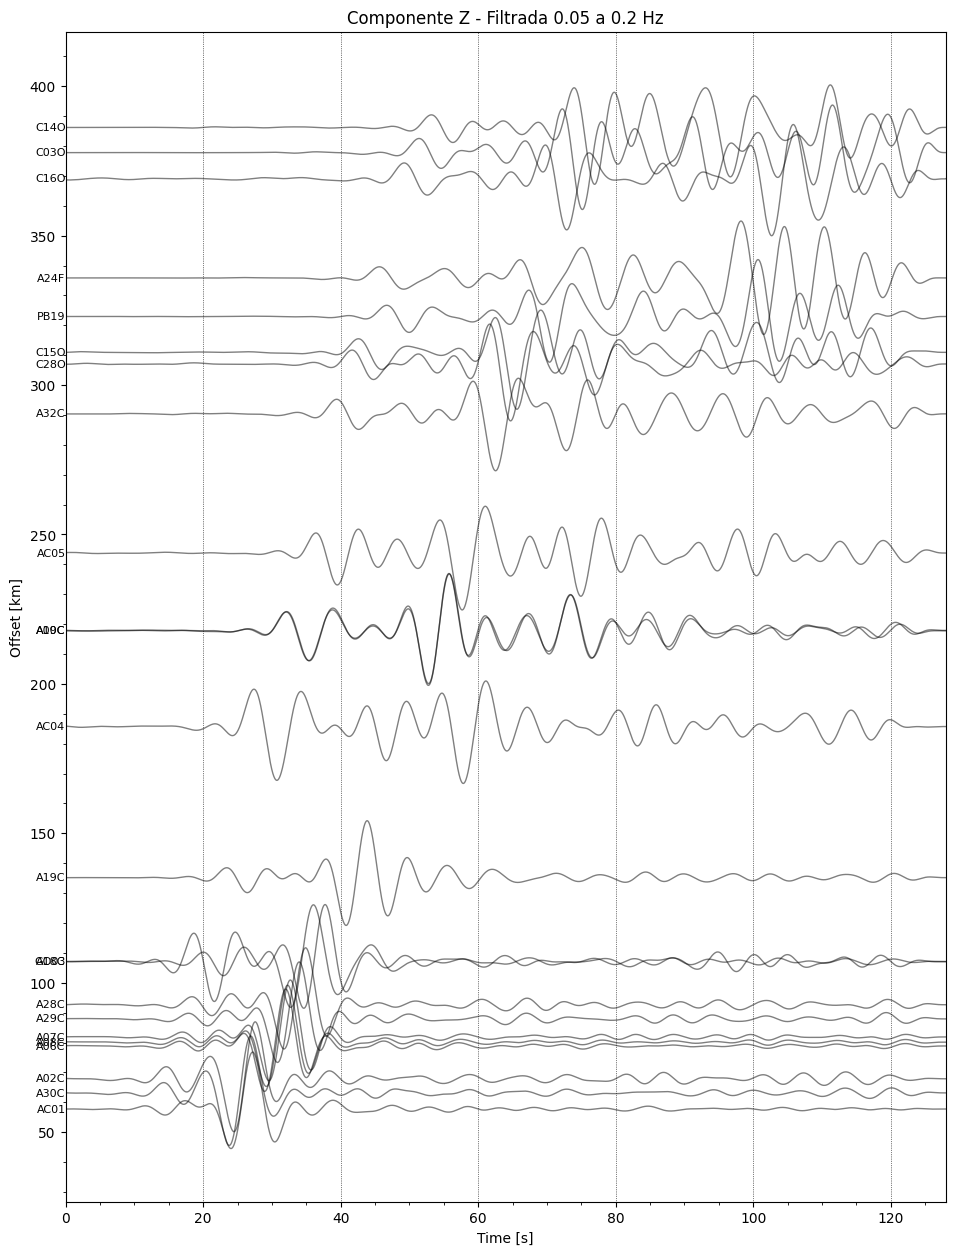

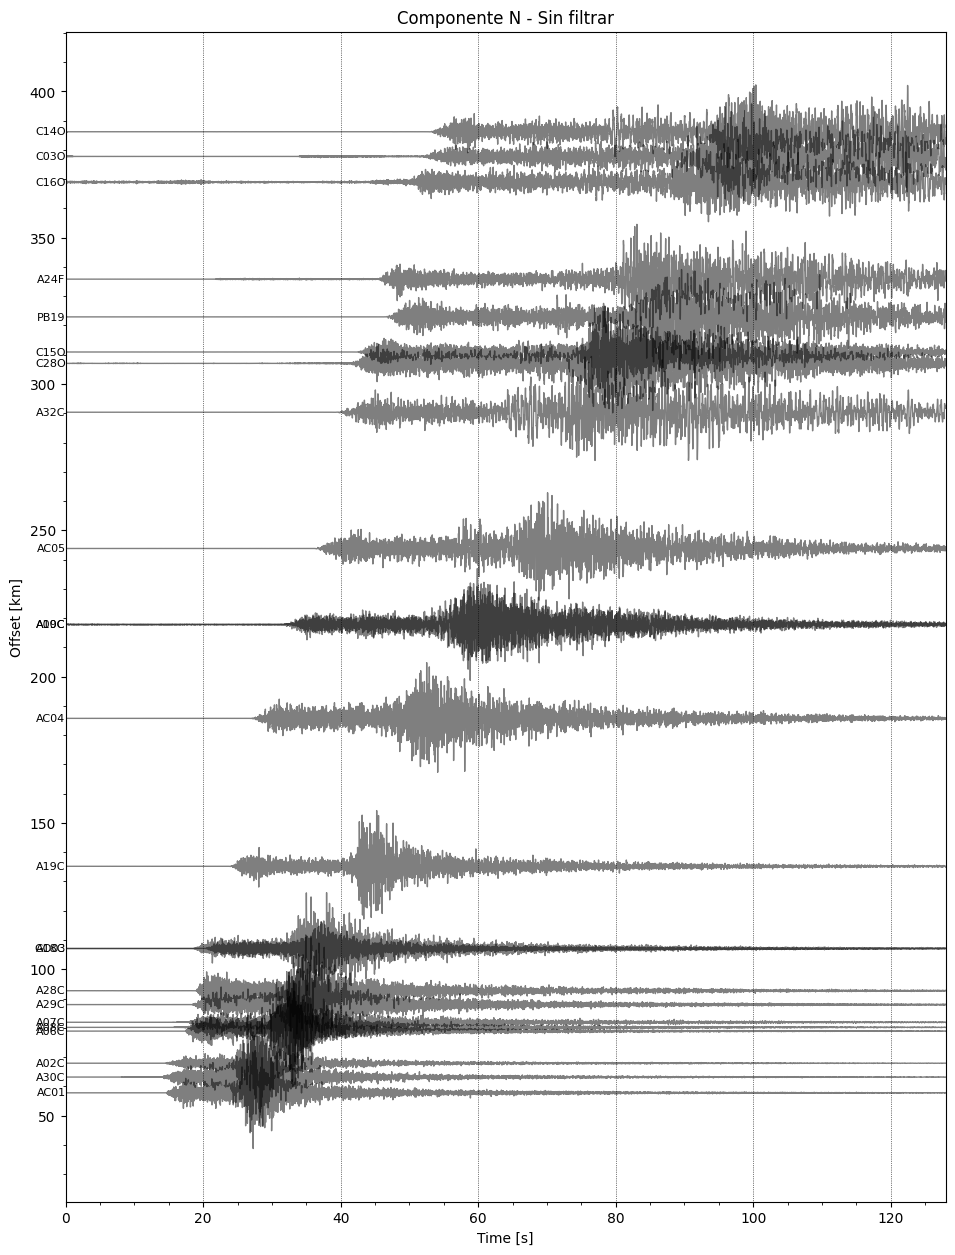

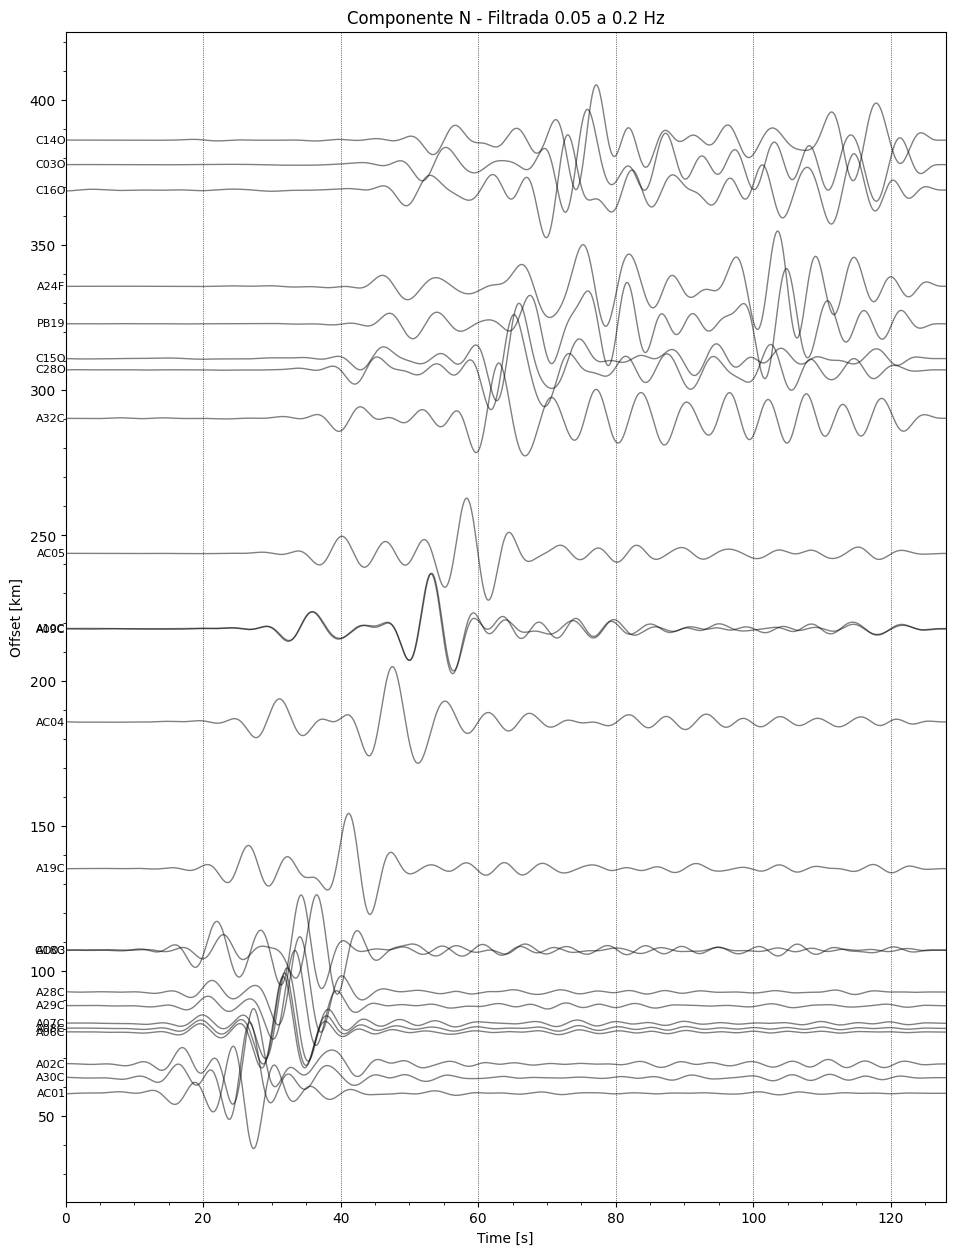

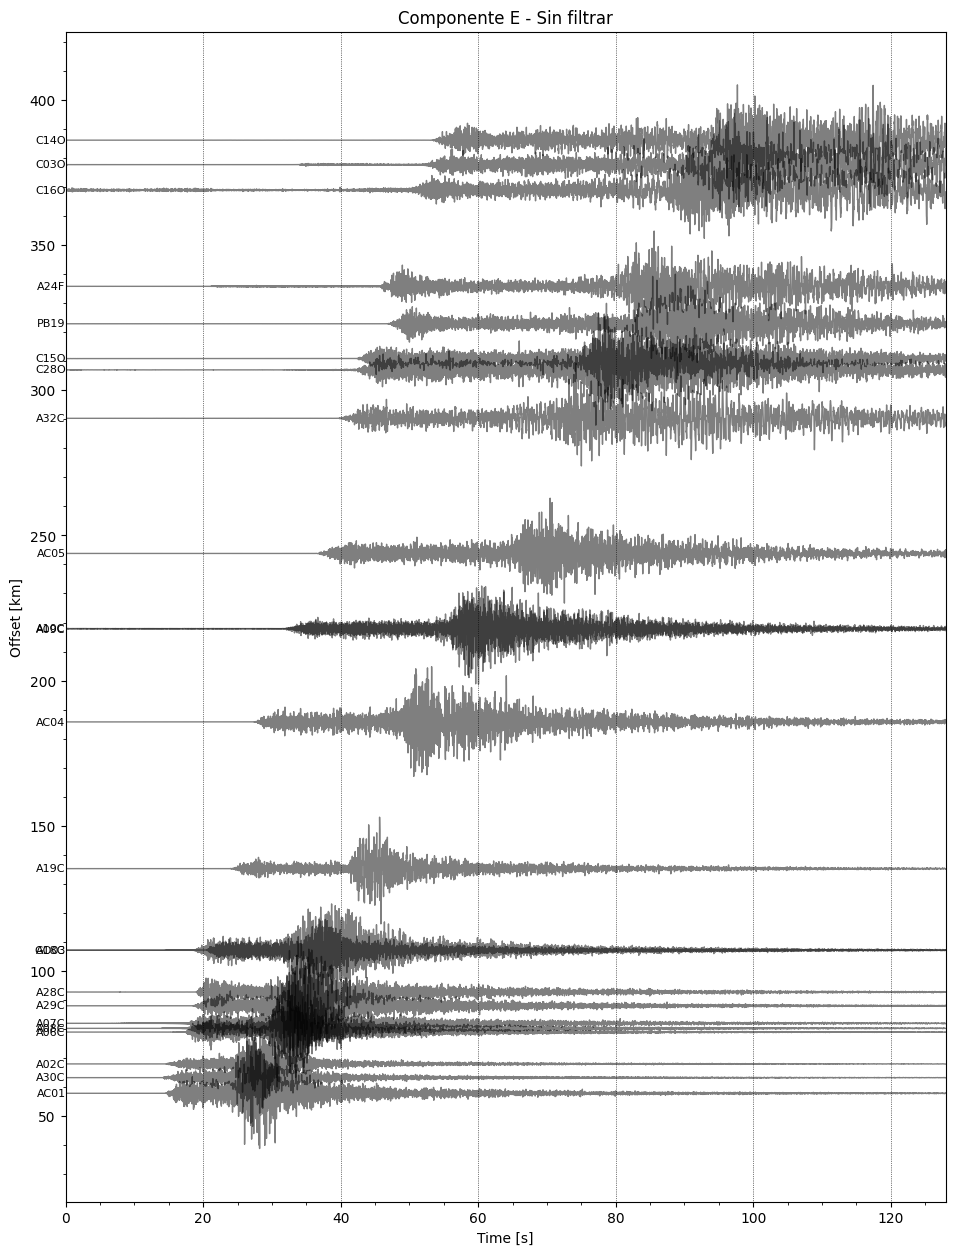

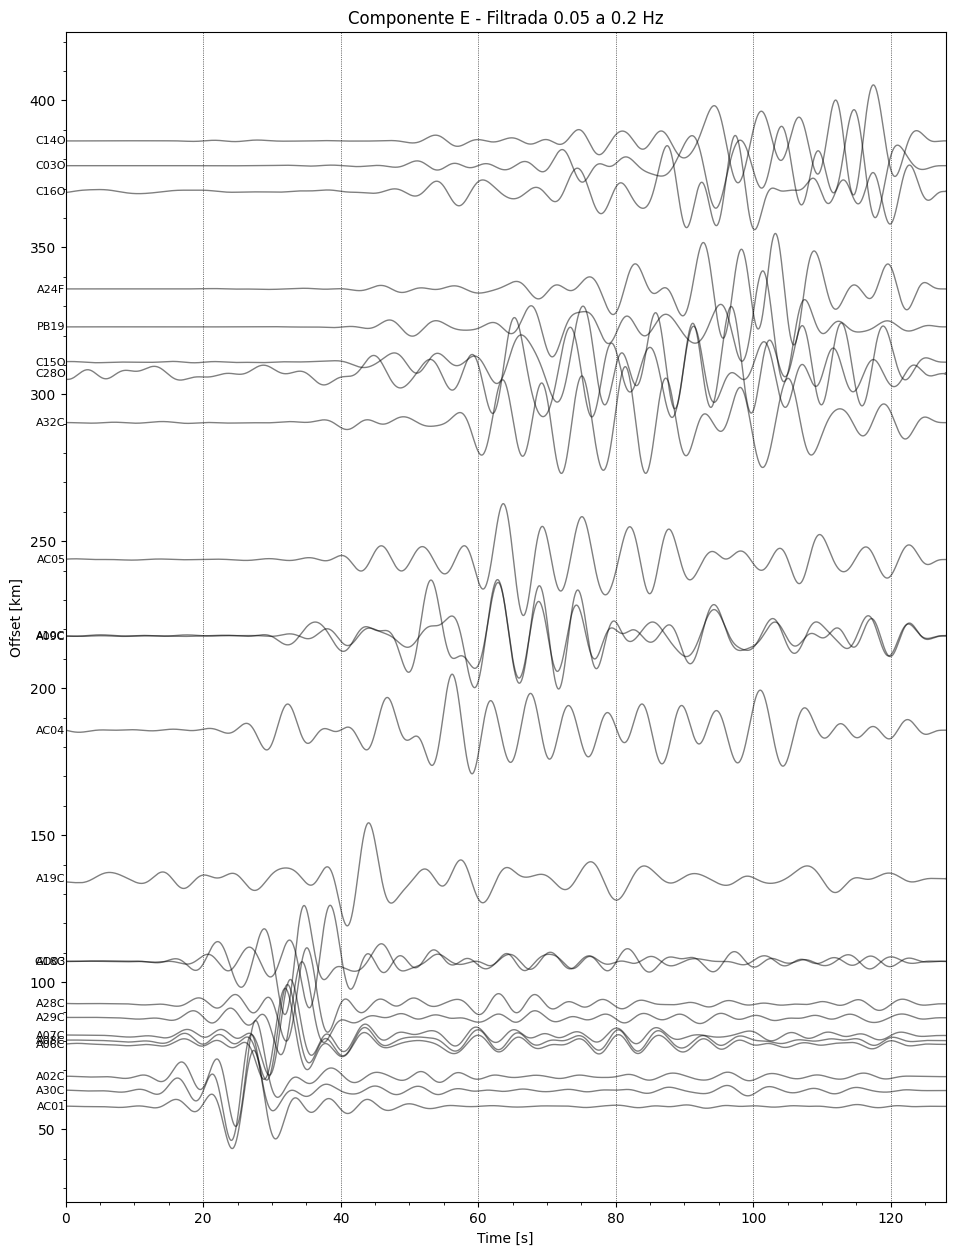

In [26]:
evlat, evlon = -26.639, -70.404
evtime = obspy.UTCDateTime("2025-06-06T17:15:06.000")

data2 = data.copy()
for tr in data2:
    tr.trim(starttime=evtime, endtime=evtime+128, fill_value=0, pad=True)
    stlat, stlon = tr.stats.sac.stla, tr.stats.sac.stlo
    tr.stats.distance = obspy.geodetics.gps2dist_azimuth(evlat, evlon, stlat, stlon)[0]

data2_filt = data2.copy()
for trf in data2_filt:
    trf.filter('bandpass', freqmin=0.05, freqmax=0.2, corners=4, zerophase=True)

for comp in ['Z', 'N', 'E']:
    # Sin filtrar
    st_comp = data2.select(channel=f'*{comp}')
    figura_sin_filtro = plt.figure(figsize=(10, 15))
    st_comp.plot(
        type='section',
        orientation='horizontal',
        scale=2.0,
        fig=figura_sin_filtro
    )
    ax = figura_sin_filtro.axes[0]
    ax.set_title(f'Componente {comp} - Sin filtrar')

    for tr in st_comp:
        sta = getattr(tr.stats, "station", getattr(tr.stats.sac, "kstnm", ""))
        ax.text(
            0, tr.stats.distance/1000, sta,
            transform=ax.get_yaxis_transform(),
            ha='right', va='center', fontsize=8
        )

    figura_sin_filtro.savefig(f'{comp}_sin_filtrar.png', dpi=300, bbox_inches='tight')

    # Filtrada
    st_comp_f = data2_filt.select(channel=f'*{comp}')
    figura_filtrada = plt.figure(figsize=(10, 15))
    st_comp_f.plot(
        type='section',
        orientation='horizontal',
        scale=2.0,
        fig=figura_filtrada
    )
    ax = figura_filtrada.axes[0]
    ax.set_title(f'Componente {comp} - Filtrada 0.05 a 0.2 Hz')

    for tr in st_comp_f:
        sta = getattr(tr.stats, "station", getattr(tr.stats.sac, "kstnm", ""))
        ax.text(
            0, tr.stats.distance/1000, sta,
            transform=ax.get_yaxis_transform(),
            ha='right', va='center', fontsize=8
        )

    figura_filtrada.savefig(f'{comp}_filtrada_0p05_0p2.png', dpi=300, bbox_inches='tight')

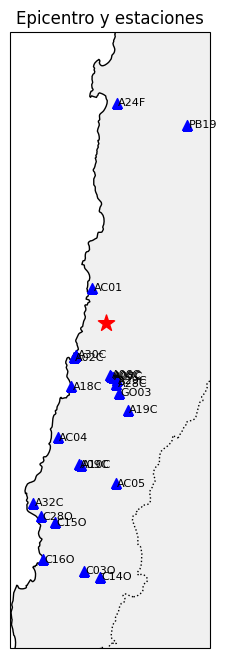

In [28]:
# Mapa con epicentro y estaciones
stations = {}
for tr in data:
    try:
        lat = tr.stats.sac.stla
        lon = tr.stats.sac.stlo
        name = getattr(tr.stats, "station", getattr(tr.stats.sac, "kstnm", ""))
        if name:
            stations[name] = (lat, lon)
    except Exception:
        continue

lats = [v[0] for v in stations.values()]
lons = [v[1] for v in stations.values()]

# Determinar límites con margen
all_lats = lats + [evlat]
all_lons = lons + [evlon]
lat_min, lat_max = min(all_lats), max(all_lats)
lon_min, lon_max = min(all_lons), max(all_lons)
lat_margin = (lat_max - lat_min) * 0.15 if (lat_max - lat_min) != 0 else 0.5
lon_margin = (lon_max - lon_min) * 0.15 if (lon_max - lon_min) != 0 else 0.5

# Intentar usar cartopy si está disponible, si no usar matplotlib simple
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    fig = plt.figure(figsize=(8, 8))
    ax_map = plt.axes(projection=ccrs.PlateCarree())
    ax_map.add_feature(cfeature.LAND, facecolor="#f0f0f0")
    ax_map.add_feature(cfeature.COASTLINE)
    ax_map.add_feature(cfeature.BORDERS, linestyle=":")

    ax_map.scatter(lons, lats, marker="^", color="blue", s=50, transform=ccrs.PlateCarree(), zorder=3)
    ax_map.scatter([evlon], [evlat], marker="*", color="red", s=150, transform=ccrs.PlateCarree(), zorder=4)

    for name, (lat, lon) in stations.items():
        ax_map.text(lon + 0.02, lat, name, transform=ccrs.PlateCarree(), fontsize=8, va="center")

    ax_map.set_extent([lon_min - lon_margin, lon_max + lon_margin, lat_min - lat_margin, lat_max + lat_margin])
    ax_map.set_title("Epicentro y estaciones")
    plt.show()

except Exception:
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(lons, lats, marker="^", color="blue", s=50)
    ax.scatter([evlon], [evlat], marker="*", color="red", s=150)
    for name, (lat, lon) in stations.items():
        ax.text(lon + 0.02, lat, name, fontsize=8, va="center")
    ax.set_xlim(lon_min - lon_margin, lon_max + lon_margin)
    ax.set_ylim(lat_min - lat_margin, lat_max + lat_margin)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Epicentro y estaciones")
    ax.grid(True)
    ax.set_aspect("equal", adjustable="box")
    plt.show()
fig.savefig('Mapa.png', dpi=300, bbox_inches='tight')